
Successfully loaded 10 image pairs.


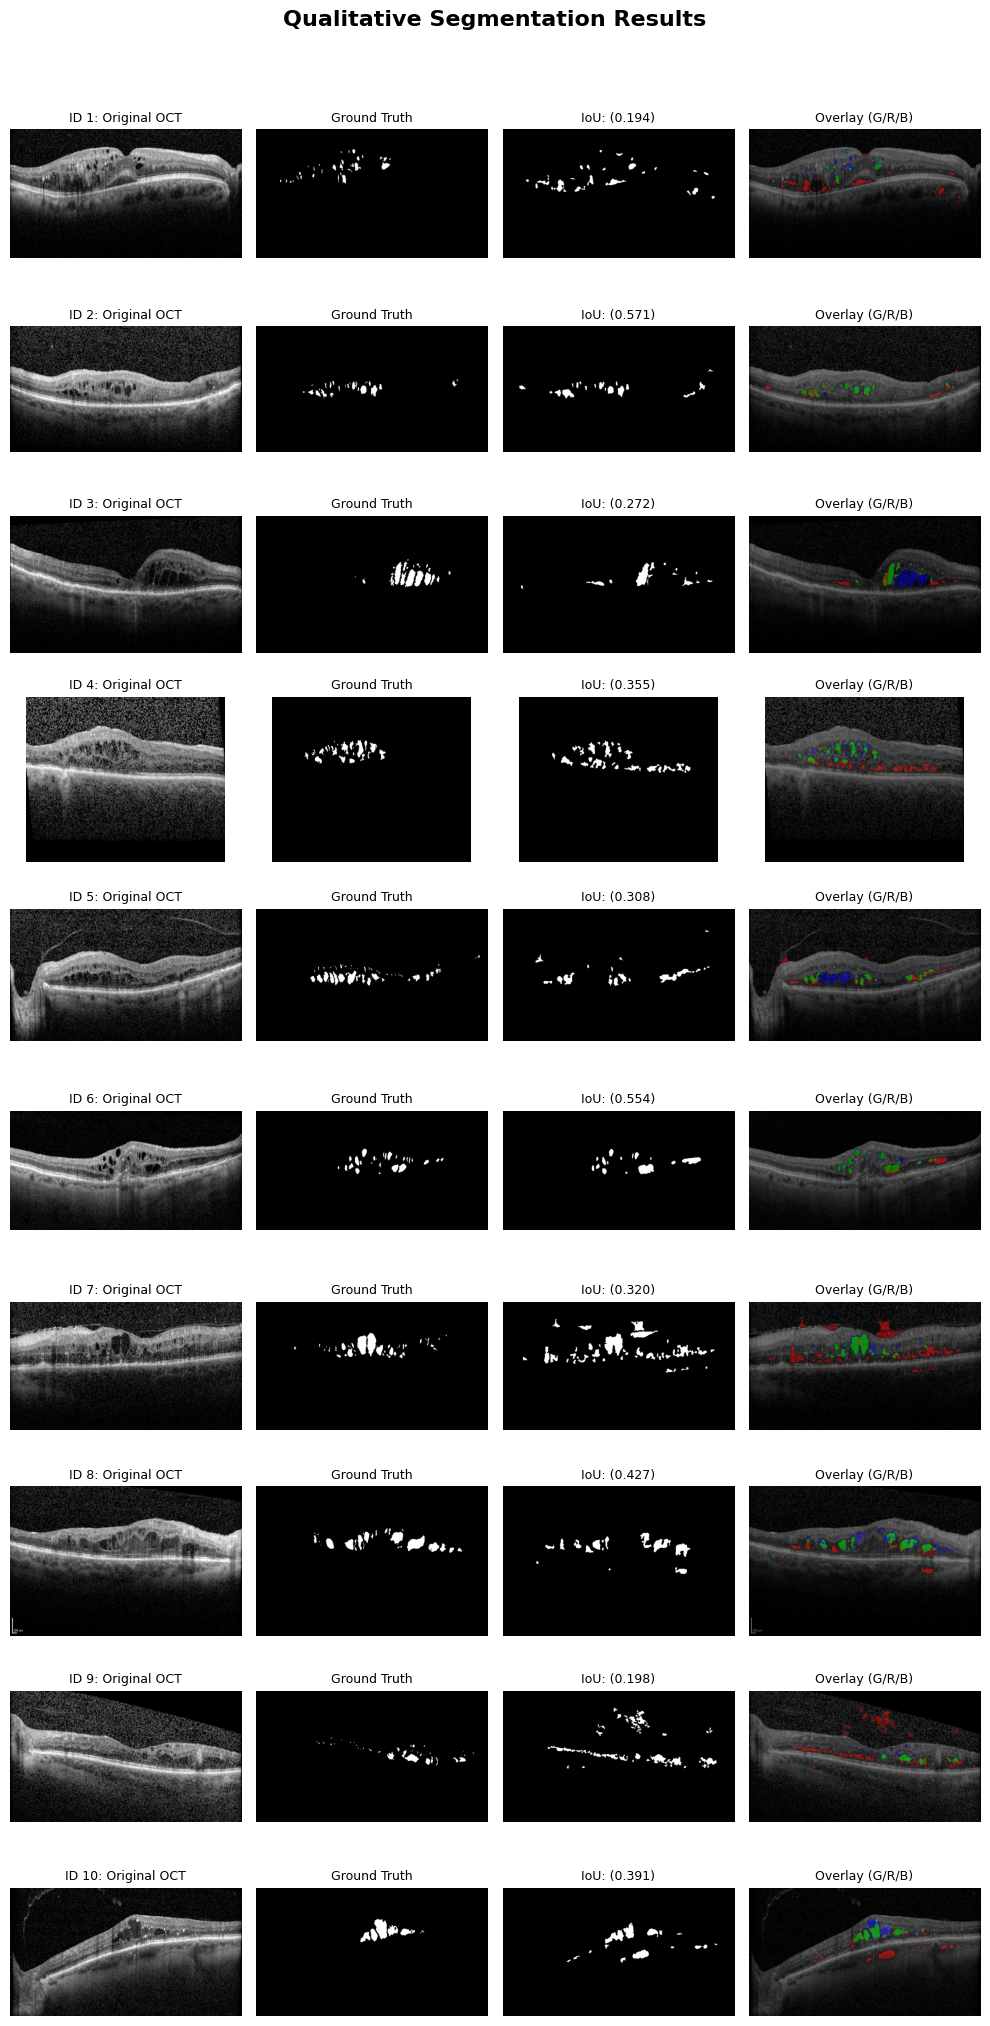


 Quantitative Segmentation Metrics 
| ID   |    IoU |   Dice |   Sensitivity |   Specificity |
|:-----|-------:|-------:|--------------:|--------------:|
| 1    | 0.1938 | 0.3247 |        0.4503 |        0.9906 |
| 10   | 0.3915 | 0.5627 |        0.5891 |        0.9926 |
| 2    | 0.5712 | 0.7271 |        0.8499 |        0.9958 |
| 3    | 0.2722 | 0.4279 |        0.3452 |        0.9956 |
| 4    | 0.3548 | 0.5238 |        0.6502 |        0.9898 |
| 5    | 0.3085 | 0.4715 |        0.4431 |        0.9933 |
| 6    | 0.5540 | 0.7130 |        0.7666 |        0.9957 |
| 7    | 0.3201 | 0.4850 |        0.7356 |        0.9768 |
| 8    | 0.4266 | 0.5981 |        0.5652 |        0.9937 |
| 9    | 0.1985 | 0.3312 |        0.6436 |        0.9837 |
| Mean | 0.3591 | 0.5165 |        0.6039 |        0.9908 |


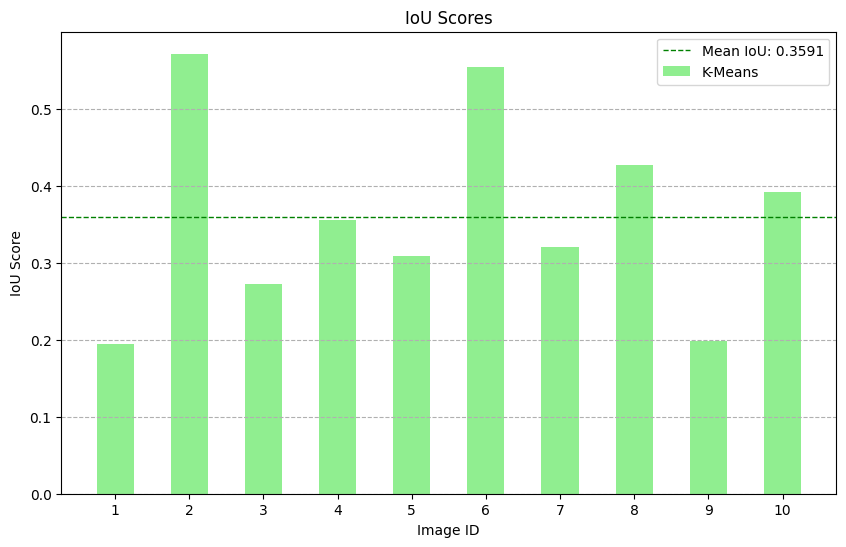

In [4]:
"""
Feature Driven K-Means Segmentation of Retinal Cysts in OCT Imaging
The pipeline demonstrates the method quantitatively and qualitatively.
"""

import os
import numpy as np
import cv2
import matplotlib.pyplot as plt
import pandas as pd
from scipy import ndimage
from skimage.measure import label, regionprops

# evaluation metrics

def calculate_metrics(gt_mask, pred_mask):
    # convert masks to boolean
    gt_mask = gt_mask.astype(bool)
    pred_mask = pred_mask.astype(bool)

    #  define true positives, false positives, false negatives, true negatives
    TP = np.sum(np.logical_and(pred_mask, gt_mask))
    FP = np.sum(np.logical_and(pred_mask, np.logical_not(gt_mask)))
    FN = np.sum(np.logical_and(np.logical_not(pred_mask), gt_mask))
    TN = np.sum(np.logical_and(np.logical_not(pred_mask), np.logical_not(gt_mask)))
    # calculates IoU, Dice, Sensitivity, and Specificity.
    IoU = TP / (TP + FP + FN) if (TP + FP + FN) > 0 else 0.0
    Dice = (2.0 * TP) / (2.0 * TP + FP + FN) if (2.0 * TP + FP + FN) > 0 else 0.0
    Sensitivity = TP / (TP + FN) if (TP + FN) > 0 else 0.0
    Specificity = TN / (TN + FP) if (TN + FP) > 0 else 0.0

    return IoU, Dice, Sensitivity, Specificity

#  data loading

def load_all_data(start_id=1, end_id=10, img_path_template='/content/img/TRAINING{}.tif', ann_path_template='/content/ann/TRAINING{}.tif'):
    # Loads all images and ground truths into a list
    all_data = []

    format_img_path = img_path_template.format(start_id)
    format_ann_path = ann_path_template.format(start_id)

    img_dir = os.path.dirname(format_img_path)
    ann_dir = os.path.dirname(format_ann_path)

    if not os.path.exists(img_dir) or not os.path.exists(ann_dir):
        print(f"Data directories not found")

    for i in range(start_id, end_id + 1):
        img_id = str(i)
        img_path = img_path_template.format(img_id)
        ann_path = ann_path_template.format(img_id)

        if os.path.exists(img_path) and os.path.exists(ann_path):
            oct_img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
            gt_ann = cv2.imread(ann_path, cv2.IMREAD_GRAYSCALE)
            gt_mask = (gt_ann > 0).astype(np.uint8)

            if oct_img is not None and gt_mask is not None:
                all_data.append({
                    'id': img_id,
                    'oct_img': oct_img,
                    'gt_mask': gt_mask
                })
        else:
            pass # skips missing files

    print(f"\nSuccessfully loaded {len(all_data)} image pairs.")
    return all_data

# Pre Processing

def create_retina_roi(oct_img):
    """
    inspired by Ganjee et al. (2020)
    creates the Region of Interest (ROI) mask for the retina.
    contrast enhancement using CLAHE.
    denoising using bilateral filter.
    OTSU thresholding to isolate bright retina region.
    morphological closing to fill gaps.
    keep largest connected component (Retina)
    """

    # CLAHE
    clahe = cv2.createCLAHE(clipLimit=1.0, tileGridSize=(8,8))
    contrast_img = clahe.apply(oct_img)

    # bilateral filter
    denoised_img = cv2.bilateralFilter(contrast_img, 9, 75, 75)

    # isolate bright regions using OTSU (retina)
    # variable ret stores the threshold value and retina_threshold stores the binary mask
    ret, retina_threshold = cv2.threshold(denoised_img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    # Morphological Closing to fill gaps
    kernel_close = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (20, 20))
    retina_closed = cv2.morphologyEx(retina_threshold, cv2.MORPH_CLOSE, kernel_close, iterations=2)

    # CCA to keep the largest connected component (Retina)
    labels, num_labels = ndimage.label(retina_closed)
    if num_labels > 0:
        regions = regionprops(labels)
        largest_label = max(regions, key=lambda region: region.area).label
        retina_roi_mask = (labels == largest_label).astype(np.uint8) * 255
    else:
        retina_roi_mask = np.zeros_like(oct_img, dtype=np.uint8)

    return denoised_img, retina_roi_mask

#  segmentaion: feature driven K-means clustering

def cyst_segmentation(oct_img, K=3, epsilon=1.0, max_iter=50, attempts=5):
    """
    Method K-Means Clustering Inspired by Girish et al. (2020)
    driven by Intensity and (Blobness) to reliably
    separate dark cysts from bright backgrounds.
    """
    denoised_img, retina_roi_mask = create_retina_roi(oct_img)

    rows, cols = denoised_img.shape

    # blobness feature extraction
    kernel_bh = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (15, 15))
    blackhat_img = cv2.morphologyEx(denoised_img, cv2.MORPH_BLACKHAT, kernel_bh)

    # reshape images into a 2-column feature set: [Intensity, Blobness]
    feature_data = np.float32(np.column_stack([
        denoised_img.flatten(),
        blackhat_img.flatten()
    ]))

    # K-Means Clustering
    criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, max_iter, epsilon)
    ret, labels, centers = cv2.kmeans(
        feature_data, K, None, criteria, attempts, cv2.KMEANS_PP_CENTERS
    )

    # reshape labels back to the original image dimensions
    clustered_labels = labels.reshape(rows, cols)

    # Identify the Cyst Cluster

    # in case clustering fails
    if centers.shape[0] < K:
         print(f"Warning: K-Means found only {centers.shape[0]} clusters.")
         return np.zeros_like(oct_img, dtype=np.uint8)

    # Cysts are characterized by low intensity and high blobness
    center_metrics = []
    for label_idx in range(K):
        mean_intensity = centers[label_idx, 0]
        mean_blobness = centers[label_idx, 1]

        # Calculate a score: Low Intensity + High Blobness = Low Score
        # Using subtraction here prioritizes both features
        score = mean_intensity - mean_blobness

        center_metrics.append({
            'label': label_idx,
            'score': score
        })

    # select the cluster with the lowest score
    cyst_cluster_label = min(center_metrics, key=lambda x: x['score'])['label']

    # extract and mask the Cyst Region
    cyst_mask_raw = (clustered_labels == cyst_cluster_label).astype(np.uint8) * 255

    # Apply the Retina ROI Mask
    final_segmented_mask = cv2.bitwise_and(cyst_mask_raw, retina_roi_mask)

    # post-processing Cleanup
    binary_mask = (final_segmented_mask > 0).astype(np.uint8)

    # Morphological closing for smoothing and small gap filling
    kernel_smooth = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
    smoothed_mask = cv2.morphologyEx(binary_mask, cv2.MORPH_CLOSE, kernel_smooth)

    # binary hole filling to ensure segmented cysts are solid
    #
    filled_mask = ndimage.binary_fill_holes(smoothed_mask).astype(np.uint8)

    # size based filtering to remove small objects (noise)
    labeled_array, num_features = ndimage.label(filled_mask)


    MIN_SIZE = 30

    if num_features > 0:
        sizes = ndimage.sum(filled_mask, labeled_array, range(num_features + 1))
        # keep components larger than MIN_SIZE
        mask_size = sizes < MIN_SIZE
        remove_pixel = mask_size[labeled_array]
        cleaned_mask = np.where(remove_pixel, 0, filled_mask)
    else:
        cleaned_mask = filled_mask

    # near-edge object removal
    edge_margin = 50  # pixels from the border
    labeled_array, num_features = ndimage.label(cleaned_mask)
    if num_features > 0:
      for region in regionprops(labeled_array):
        minr, minc, maxr, maxc = region.bbox
        if (minr <= edge_margin or minc <= edge_margin or
            maxr >= rows - edge_margin or maxc >= cols - edge_margin):
            cleaned_mask[labeled_array == region.label] = 0
    # bottom margin removal
    bottom_margin = 175 # number of pixels away from the bottom
    for region in regionprops(labeled_array):
      if region.bbox[2] >= binary_mask.shape[0] - bottom_margin:
        cleaned_mask[labeled_array == region.label] = 0


    return cleaned_mask.astype(np.uint8)


# visualization

def visualize_results(oct_img, gt_mask, pred_mask, iou, ax, title):
    # displays the required visualizations

    # create overlay
    def create_overlay(base_img, pred_mask, gt_mask, alpha=0.5):
        TP = np.logical_and(pred_mask, gt_mask)
        FP = np.logical_and(pred_mask, np.logical_not(gt_mask))
        FN = np.logical_and(np.logical_not(pred_mask), gt_mask)

        # convert image to 3-channel for color overlay
        mask_vis = np.stack([base_img] * 3, axis=-1)
        color_mask = np.zeros_like(mask_vis, dtype=np.uint8)
        color_mask[FP] = [255, 0, 0] # Red (False Positive)
        color_mask[FN] = [0, 0, 255] # Blue (False Negative)
        color_mask[TP] = [0, 255, 0] # Green (True Positive)

        return cv2.addWeighted(mask_vis, 1 - alpha, color_mask, alpha, 0)

    # 1. Original OCT
    ax[0].imshow(oct_img, cmap='gray')
    ax[0].set_title(f'{title}: Original OCT', fontsize=9)
    ax[0].axis('off')

    # 2. Ground Truth
    ax[1].imshow(gt_mask, cmap='gray')
    ax[1].set_title('Ground Truth', fontsize=9)
    ax[1].axis('off')

    # 3. Predicted Mask
    ax[2].imshow(pred_mask, cmap='gray')
    ax[2].set_title(f'IoU: ({iou:.3f})', fontsize=9)
    ax[2].axis('off')

    # 4. Overlay
    overlay= create_overlay(oct_img, pred_mask, gt_mask)
    ax[3].imshow(overlay)
    ax[3].set_title('Overlay (G/R/B)', fontsize=9)
    ax[3].axis('off')


#  main execution

if __name__ == '__main__':

    IMG_BASE_PATH = '/content/img/TRAINING{}.tif'
    ANN_BASE_PATH = '/content/ann/TRAINING{}.tif'

    # load images and annotatoins into variable (all_data)
    all_data = load_all_data(start_id=1, end_id=10, img_path_template=IMG_BASE_PATH, ann_path_template=ANN_BASE_PATH)

    if not all_data:
        print("\n No image pairs loaded.")
    else:
        results_list = []
        num_images = len(all_data)

        # setup visualization grid (4 plots: original, annotation, predicted mask, G/R/B overlay)
        cols = 4
        rows = num_images

        # adjust figsize to accommodate number of rows
        fig, axes = plt.subplots(rows, cols, figsize=(cols * 2.5, rows * 2.0))
        plt.subplots_adjust(hspace=0.4, wspace=0.1)

        iou_scores = []

        # best parameters (found using tuning loops)
        best_K = 3
        best_epsilon = 1.0
        best_max_iter = 50
        best_attempts = 5


        for idx, data in enumerate(all_data):
            img_id = data['id']
            oct_img = data['oct_img']
            gt_mask = data['gt_mask']

            # segmenation
            pred_mask = cyst_segmentation(
                oct_img,
                K=best_K,
                epsilon=best_epsilon,
                max_iter=best_max_iter,
                attempts=best_attempts
            )

            # calculate evaluation metrics for predicted mask
            IoU, Dice, Sensitivity, Specificity = calculate_metrics(gt_mask, pred_mask)
            iou_scores.append(IoU)


            # store results
            results_list.append({
                'ID': img_id,
                'IoU': IoU, 'Dice': Dice, 'Sensitivity': Sensitivity, 'Specificity': Specificity
            })

            # visualize qualitative results
            # handles both single and multiple image case for indexing axes
            current_axes = axes[idx] if num_images > 1 else axes

            visualize_results(
                oct_img, gt_mask,
                pred_mask, IoU,
                current_axes,
                f'ID {img_id}'
            )

        plt.suptitle("Qualitative Segmentation Results", y=1.02, fontsize=16, fontweight='bold')
        plt.tight_layout(rect=[0, 0, 1, 1.0])
        plt.show()

        # quantitative results table

        df_results = pd.DataFrame(results_list)
        df_mean = df_results[['IoU', 'Dice', 'Sensitivity', 'Specificity']].mean(numeric_only=True).to_frame().T
        df_mean['ID'] = 'Mean'

        df_final = pd.concat([df_results, df_mean], ignore_index=True).sort_values(by='ID').set_index('ID')

        print("\n Quantitative Segmentation Metrics ")
        print(df_final.round(4).to_markdown(floatfmt=".4f"))

        # qauntitative results graph

        plt.figure(figsize=(10, 6))

        image_ids = [result['ID'] for result in results_list if result['ID'] != 'Mean']
        iou_values = [result['IoU'] for result in results_list if result['ID'] != 'Mean']


        X = np.arange(len(image_ids))
        width = 0.5

        plt.bar(X, iou_values, width, label='K-Means', color='lightgreen')

        # get the mean IoU from the df_mean dataframe
        mean_iou = df_mean['IoU'].iloc[0]

        plt.axhline(mean_iou, color='green', linestyle='--', linewidth=1, label=f'Mean IoU: {mean_iou:.4f}')

        plt.xticks(X, image_ids)
        plt.title('IoU Scores')
        plt.xlabel('Image ID')
        plt.ylabel('IoU Score')
        plt.legend()
        plt.grid(axis='y', linestyle='--')
        plt.show()